
Noise summary: pooled over all ICs and times
--------------------------------------------
AR(1) rho_true                     :  0.5000
Mean signed noise                  : -5.465920e-04
Std of signed noise                :  6.854752e-02
Mean absolute noise                :  4.770684e-02
Median absolute noise              :  2.790910e-02
RMSE noise                         :  6.819177e-02
Max absolute noise                 :  2.281295e-01
Mean percentage error (MPE)        : -0.267634%
Mean abs percentage error (MAPE)   :  7.074350%
Median abs percentage error        :  6.350242%
Symmetric MAPE (sMAPE)             :  7.126572%
Mean true sigma(N)                 :  6.299866e-02
Mean |noise| / sigma_true(N)       :  0.707435
Std of standardized noise z        :  0.883573
Mean of standardized noise z       : -0.026763

Observed-point noise table
--------------------------

Trajectory 1 (IC = 0.10)
t        true        data        noise       abs%err     sigma_true    z=noise/sigma
 0.000  

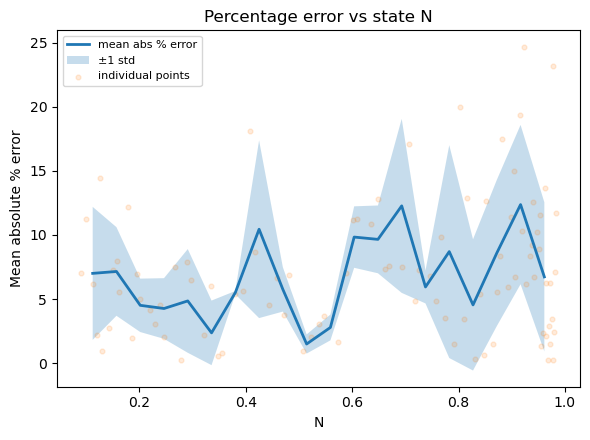


Mean percentage error by N bin
--------------------------------
N≈0.112 | mean % error =  7.002% | std =  5.186% | samples = 6
N≈0.157 | mean % error =  7.150% | std =  3.455% | samples = 5
N≈0.202 | mean % error =  4.511% | std =  2.082% | samples = 4
N≈0.246 | mean % error =  4.263% | std =  2.365% | samples = 4
N≈0.291 | mean % error =  4.854% | std =  4.043% | samples = 3
N≈0.336 | mean % error =  2.364% | std =  2.518% | samples = 4
N≈0.380 | mean % error =  5.500% | std =  0.127% | samples = 2
N≈0.425 | mean % error = 10.444% | std =  6.928% | samples = 3
N≈0.470 | mean % error =  5.753% | std =  1.730% | samples = 3
N≈0.514 | mean % error =  1.495% | std =  0.746% | samples = 2
N≈0.559 | mean % error =  2.786% | std =  1.006% | samples = 3
N≈0.604 | mean % error =  9.833% | std =  2.397% | samples = 3
N≈0.649 | mean % error =  9.653% | std =  2.643% | samples = 4
N≈0.693 | mean % error = 12.266% | std =  6.786% | samples = 2
N≈0.738 | mean % error =  5.942% | std =  1.282% | sa

In [19]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.10, 0.12, 0.13, 0.09]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# AR(1) heteroscedastic Gaussian NLL
# ============================================================
def ar1_gaussian_nll(resid, sigma, rho, eps=1e-6, reduce="mean"):
    """
    AR(1) heteroscedastic Gaussian negative log-likelihood.

    Model:
        e_0 ~ N(0, sigma_0^2)
        e_k | e_{k-1} ~ N(rho e_{k-1}, (1-rho^2) sigma_k^2)
    """
    resid = resid.reshape(-1)
    sigma = sigma.reshape(-1).clamp_min(eps)

    sigma2 = sigma ** 2
    one_minus_rho2 = max(1.0 - rho ** 2, eps)

    term0 = torch.log(sigma2[0]) + resid[0] ** 2 / sigma2[0]

    innov = resid[1:] - rho * resid[:-1]
    var_innov = one_minus_rho2 * sigma2[1:]
    terms_rest = torch.log(var_innov) + innov ** 2 / var_innov

    terms = torch.cat([term0.view(1), terms_rest], dim=0)

    if reduce == "sum":
        return 0.5 * torch.sum(terms)
    elif reduce == "mean":
        return 0.5 * torch.mean(terms)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def ar1_gaussian_nll_batch(resid_all, sigma_all, rho, eps=1e-6, reduce="mean"):
    """
    resid_all : [B, T, 1] or [B, T]
    sigma_all : [B, T, 1] or [B, T]
    """
    if resid_all.ndim == 2:
        resid_all = resid_all.unsqueeze(-1)
    if sigma_all.ndim == 2:
        sigma_all = sigma_all.unsqueeze(-1)

    B = resid_all.shape[0]
    losses = []
    for b in range(B):
        losses.append(
            ar1_gaussian_nll(
                resid_all[b], sigma_all[b], rho, eps=eps, reduce="mean"
            )
        )
    losses = torch.stack(losses)

    if reduce == "mean":
        return losses.mean()
    elif reduce == "sum":
        return losses.sum()
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law: heteroscedastic + AR(1) correlated in time
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


def sample_ar1_noise_from_sigma(sigma_t, rho):
    """
    Sample heteroscedastic AR(1) noise with marginal std sigma_t.

    e_0 ~ N(0, sigma_0^2)
    e_k = rho e_{k-1} + sqrt(1-rho^2) sigma_k xi_k
    """
    sigma_t = sigma_t.reshape(-1, 1)
    T = sigma_t.shape[0]

    eps = torch.randn_like(sigma_t)
    noise = torch.zeros_like(sigma_t)

    noise[0] = sigma_t[0] * eps[0]
    scale = torch.sqrt(torch.tensor(max(1.0 - rho**2, 1e-8), device=sigma_t.device))

    for k in range(1, T):
        noise[k] = rho * noise[k - 1] + scale * sigma_t[k] * eps[k]

    return noise


y_true_list = []
y_data_list = []
noise_list = []

noise_sig_coeff = 0.1
gamma = 1.0
rho_true = 0.5   # <-- temporal correlation of the synthetic observation noise

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

        sigma_t = noise_sig_coeff * y_true**gamma
        noise_t = sample_ar1_noise_from_sigma(sigma_t, rho=rho_true)
        y_data = y_true + noise_t

        y_true_list.append(y_true)
        y_data_list.append(y_data)
        noise_list.append(noise_t)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, T, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, T, 1]
noise_all  = torch.stack(noise_list,  dim=0)   # [n_ics, T, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = noise_sig_coeff * N_grid**gamma


# ============================================================
# Noise statistics
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    sigma_true_obs_np = (noise_sig_coeff * (y_true_all.squeeze(-1) ** gamma)).cpu().numpy()

    eps = 1e-12
    denom_true = np.maximum(np.abs(y_true_np), eps)
    denom_sym = np.maximum(np.abs(y_true_np) + np.abs(y_data_np), eps)

    pct_error_np = 100.0 * noise_np / denom_true
    abs_pct_error_np = 100.0 * abs_noise_np / denom_true
    smape_np = 100.0 * 2.0 * abs_noise_np / denom_sym

    z_np = noise_np / np.maximum(sigma_true_obs_np, eps)

    print("\nNoise summary: pooled over all ICs and times")
    print("--------------------------------------------")
    print(f"AR(1) rho_true                     : {rho_true: .4f}")
    print(f"Mean signed noise                  : {noise_np.mean(): .6e}")
    print(f"Std of signed noise                : {noise_np.std(ddof=1): .6e}")
    print(f"Mean absolute noise                : {abs_noise_np.mean(): .6e}")
    print(f"Median absolute noise              : {np.median(abs_noise_np): .6e}")
    print(f"RMSE noise                         : {np.sqrt(np.mean(noise_np**2)): .6e}")
    print(f"Max absolute noise                 : {abs_noise_np.max(): .6e}")
    print(f"Mean percentage error (MPE)        : {pct_error_np.mean(): .6f}%")
    print(f"Mean abs percentage error (MAPE)   : {abs_pct_error_np.mean(): .6f}%")
    print(f"Median abs percentage error        : {np.median(abs_pct_error_np): .6f}%")
    print(f"Symmetric MAPE (sMAPE)             : {smape_np.mean(): .6f}%")
    print(f"Mean true sigma(N)                 : {sigma_true_obs_np.mean(): .6e}")
    print(f"Mean |noise| / sigma_true(N)       : {np.mean(abs_noise_np / np.maximum(sigma_true_obs_np, eps)): .6f}")
    print(f"Std of standardized noise z        : {z_np.std(ddof=1): .6f}")
    print(f"Mean of standardized noise z       : {z_np.mean(): .6f}")


# ============================================================
# Optional: pointwise table of true/data/noise/%error
# ============================================================
print("\nObserved-point noise table")
print("--------------------------")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (IC = {N0_list[i]:.2f})")
    print("t        true        data        noise       abs%err     sigma_true    z=noise/sigma")
    for ti, yt, yd, en, ape, sigi, zi in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_np[i],
        y_data_np[i],
        noise_np[i],
        abs_pct_error_np[i],
        sigma_true_obs_np[i],
        z_np[i],
    ):
        print(
            f"{ti:6.3f}   {yt:9.5f}   {yd:9.5f}   {en:9.5f}   "
            f"{ape:9.3f}%   {sigi:11.5e}   {zi:9.4f}"
        )


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def g_zero_nonnegative_penalty(dyn_net):
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


# ============================================================
# Fit sigma using AR(1) likelihood
# ============================================================
def fit_sigma_repeated(
    N_all_seq,              # [B, T, 1]
    resid_all_seq,          # [B, T, 1]
    N_eval_grid,
    N_col_base,
    rho_assumed=0.85,       # <-- assumed temporal correlation in the fit
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=1000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    B = N_all_seq.shape[0]
    use_validation = val_fraction > 0.0 and B > 1

    if use_validation:
        n_val = int(round(val_fraction * B))
        n_val = max(1, min(n_val, B - 1))
    else:
        n_val = 0
    n_train = B - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(B, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all_seq[train_idx]
        r_train = resid_all_seq[train_idx]

        if use_validation:
            N_val = N_all_seq[val_idx]
            r_val = resid_all_seq[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)  # [B, T, 1]
            train_nll = ar1_gaussian_nll_batch(
                r_train, sigma_pred_train, rho=rho_assumed, reduce="mean"
            )
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = ar1_gaussian_nll_batch(
                        r_val, sigma_pred_val, rho=rho_assumed, reduce="mean"
                    )

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e}"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# Example of what to pass into fit_sigma_repeated
# ============================================================
# If residuals are just the observation noise relative to truth:
resid_all_seq = y_data_all - y_true_all    # [B, T, 1]
N_all_seq = y_true_all                     # or your fitted state estimate, shape [B, T, 1]

# Example call:
# sigma_fit_out = fit_sigma_repeated(
#     N_all_seq=N_all_seq,
#     resid_all_seq=resid_all_seq,
#     N_eval_grid=N_grid,
#     N_col_base=N_grid,
#     rho_assumed=0.85,
#     n_repeats=3,
#     val_fraction=0.2,
#     n_epochs=2000,
#     lr=5e-3,
#     hidden_dim=8,
#     lambda_mon=1.0,
#     lambda_reg=1e-5,
#     label="sigma_ar1",
#     print_every=200,
# )


# ============================================================
# Mean percentage error as a function of N
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    eps = 1e-12
    abs_pct_error_np = 100.0 * abs_noise_np / np.maximum(np.abs(y_true_np), eps)

    # Flatten all trajectories
    N_flat = y_true_np.reshape(-1)
    pct_flat = abs_pct_error_np.reshape(-1)

    # Bin in N
    n_bins = 20
    bins = np.linspace(N_flat.min(), N_flat.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    mean_pct = np.zeros(n_bins)
    std_pct = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for i in range(n_bins):
        # include right endpoint in last bin
        if i < n_bins - 1:
            mask = (N_flat >= bins[i]) & (N_flat < bins[i + 1])
        else:
            mask = (N_flat >= bins[i]) & (N_flat <= bins[i + 1])

        if np.sum(mask) > 0:
            mean_pct[i] = pct_flat[mask].mean()
            std_pct[i] = pct_flat[mask].std(ddof=1) if np.sum(mask) > 1 else 0.0
            counts[i] = np.sum(mask)
        else:
            mean_pct[i] = np.nan
            std_pct[i] = np.nan
            counts[i] = 0


# ============================================================
# Plot mean percentage error vs N
# ============================================================
plt.figure(figsize=(6, 4.5))

plt.plot(bin_centers, mean_pct, linewidth=2, label="mean abs % error")

plt.fill_between(
    bin_centers,
    mean_pct - std_pct,
    mean_pct + std_pct,
    alpha=0.25,
    label="±1 std"
)

plt.scatter(N_flat, pct_flat, s=12, alpha=0.15, label="individual points")

plt.xlabel("N")
plt.ylabel("Mean absolute % error")
plt.title("Percentage error vs state N")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Print numeric summary
# ============================================================
print("\nMean percentage error by N bin")
print("--------------------------------")
for c, m, s, n in zip(bin_centers, mean_pct, std_pct, counts):
    if n > 0:
        print(f"N≈{c:.3f} | mean % error = {m:6.3f}% | std = {s:6.3f}% | samples = {int(n)}")



def ar1_gaussian_nll(resid, sigma, rho, eps=1e-6, reduce="mean"):
    """
    resid : [T, 1] or [T]
    sigma : [T, 1] or [T]
    rho   : scalar tensor or float with |rho| < 1
    """
    resid = resid.reshape(-1)
    sigma = sigma.reshape(-1).clamp_min(eps)

    if not torch.is_tensor(rho):
        rho = torch.tensor(rho, dtype=resid.dtype, device=resid.device)

    rho = torch.clamp(rho, -0.999, 0.999)

    sigma2 = sigma ** 2
    one_minus_rho2 = torch.clamp(1.0 - rho ** 2, min=eps)

    term0 = torch.log(sigma2[0]) + resid[0] ** 2 / sigma2[0]

    innov = resid[1:] - rho * resid[:-1]
    var_innov = one_minus_rho2 * sigma2[1:]
    terms_rest = torch.log(var_innov) + innov ** 2 / var_innov

    terms = torch.cat([term0.view(1), terms_rest], dim=0)

    if reduce == "sum":
        return 0.5 * torch.sum(terms)
    elif reduce == "mean":
        return 0.5 * torch.mean(terms)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def ar1_gaussian_nll_batch(resid_all, sigma_all, rho, eps=1e-6, reduce="mean"):
    """
    resid_all : [B, T, 1] or [B, T]
    sigma_all : [B, T, 1] or [B, T]
    """
    if resid_all.ndim == 2:
        resid_all = resid_all.unsqueeze(-1)
    if sigma_all.ndim == 2:
        sigma_all = sigma_all.unsqueeze(-1)

    losses = []
    for b in range(resid_all.shape[0]):
        losses.append(
            ar1_gaussian_nll(
                resid_all[b], sigma_all[b], rho=rho, eps=eps, reduce="mean"
            )
        )
    losses = torch.stack(losses)

    if reduce == "mean":
        return losses.mean()
    elif reduce == "sum":
        return losses.sum()
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def fit_sigma_ar1_repeated(
    N_seq_all,                # [B, T, 1]
    resid_seq_all,            # [B, T, 1]
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma-ar1",
    print_every=500,
):
    B = N_seq_all.shape[0]
    use_validation = val_fraction > 0.0 and B > 1

    if use_validation:
        n_val = int(round(val_fraction * B))
        n_val = max(1, min(n_val, B - 1))
    else:
        n_val = 0
    n_train = B - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    rho_histories = []

    best_val_losses = []
    best_epochs = []
    best_rhos = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(B, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_seq_all[train_idx]
        r_train = resid_seq_all[train_idx]

        if use_validation:
            N_val = N_seq_all[val_idx]
            r_val = resid_seq_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)

        # unconstrained parameter; rho = tanh(rho_raw)
        rho_raw = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=device))

        opt = torch.optim.Adam(
            list(sigma_net.parameters()) + [rho_raw],
            lr=lr,
        )

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None
        best_rho = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            rho = torch.tanh(rho_raw)
            sigma_pred_train = sigma_net(N_train)

            train_nll = ar1_gaussian_nll_batch(
                resid_all=r_train,
                sigma_all=sigma_pred_train,
                rho=rho,
                reduce="mean",
            )
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                rho_eval = torch.tanh(rho_raw)

                if use_validation:
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = ar1_gaussian_nll_batch(
                        resid_all=r_val,
                        sigma_all=sigma_pred_val,
                        rho=rho_eval,
                        reduce="mean",
                    )
                else:
                    val_nll = torch.tensor(np.nan, device=device)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon if use_validation else torch.tensor(np.nan, device=device)

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item() if use_validation else np.nan)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"rho={rho_eval.item(): .4f} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total.item():.6e} | "
                        f"Val NLL: {val_nll.item():.6e} | "
                        f"Val Mon: {val_mon.item():.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"rho={rho_eval.item(): .4f} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e}"
                    )

            criterion = val_total.item() if use_validation else train_total.item()

            if criterion < best_val_loss:
                best_val_loss = criterion
                best_epoch = epoch
                best_rho = torch.tanh(rho_raw).item()
                best_state = {
                    "sigma_net": copy.deepcopy(sigma_net.state_dict()),
                    "rho_raw": rho_raw.detach().clone(),
                }

        sigma_net.load_state_dict(best_state["sigma_net"])
        rho_raw_best = best_state["rho_raw"]
        rho_best = torch.tanh(rho_raw_best).item()
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        rho_histories.append(rho_best)

        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)
        best_rhos.append(rho_best)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | "
            f"Best loss = {best_val_loss:.6e} | "
            f"Best rho = {rho_best:.4f}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "rho_histories": np.array(rho_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_rhos": np.array(best_rhos),
        "best_models": best_models,
    }


Starting PINN split 1/4
Held-out validation trajectory index: 0 | IC = 0.10
Training trajectory indices: [1, 2, 3]
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20001, 20002, 20003]
PINN | Split  1/4 | Epoch     1/2000 | PINN Total: 7.046381e-01 | Optim Total: 7.046381e-01 | Train Data: 7.000637e-01 | Train Phys: 4.574414e-03 | Train IC[N(0)]: 1.245812e-02 | Heldout Rollout Val: 4.663171e-01
PINN | Split  1/4 | Epoch   500/2000 | PINN Total: 3.543292e-03 | Optim Total: 3.543292e-03 | Train Data: 3.392641e-03 | Train Phys: 1.506516e-04 | Train IC[N(0)]: 3.208715e-03 | Heldout Rollout Val: 1.245521e-02
PINN | Split  1/4 | Epoch  1000/2000 | PINN Total: 3.162923e-03 | Optim Total: 3.162923e-03 | Train Data: 3.062622e-03 | Train Phys: 1.003009e-04 | Train IC[N(0)]: 1.815456e-03 | Heldout Rollout Val: 1.050706e-02
PINN | Split  1/4 | Epoch  1500/2000 | PINN Total: 2.894467e-03 | Optim Total: 2.894467e-03 | Train Data: 2.733526e-03 | Train Phys: 1.609408e-04 | Trai

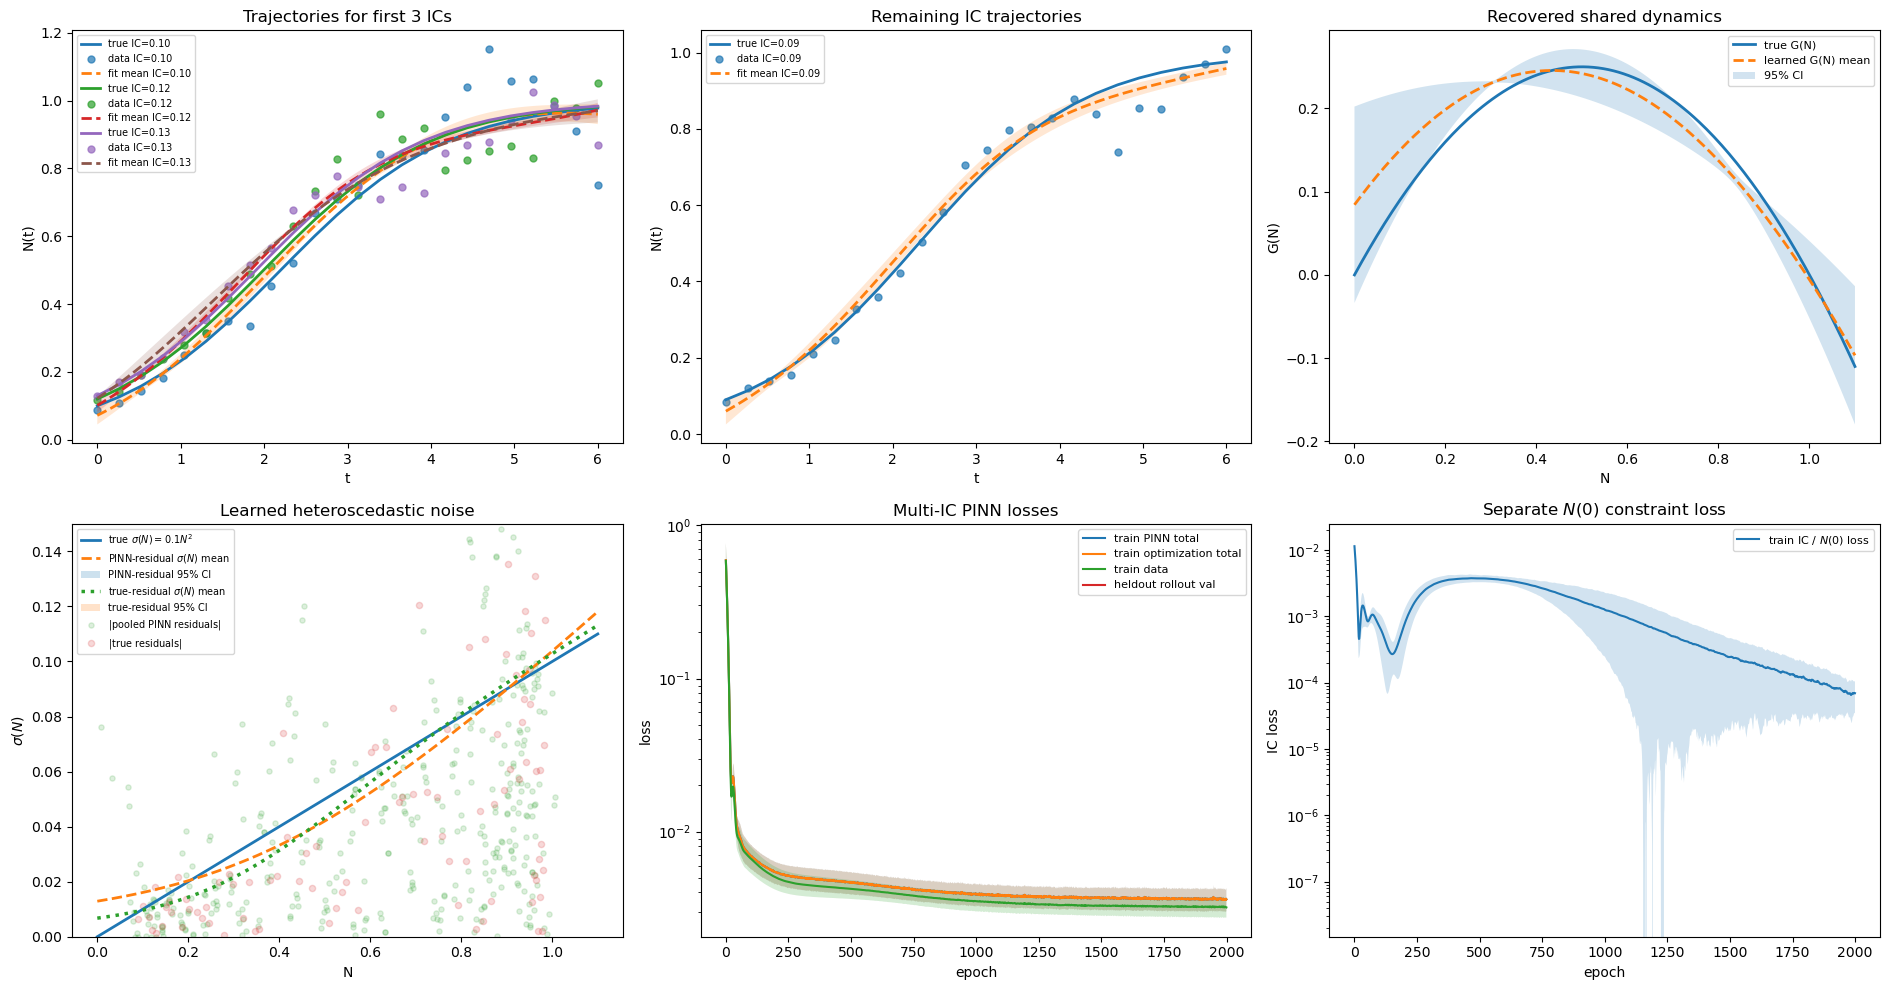

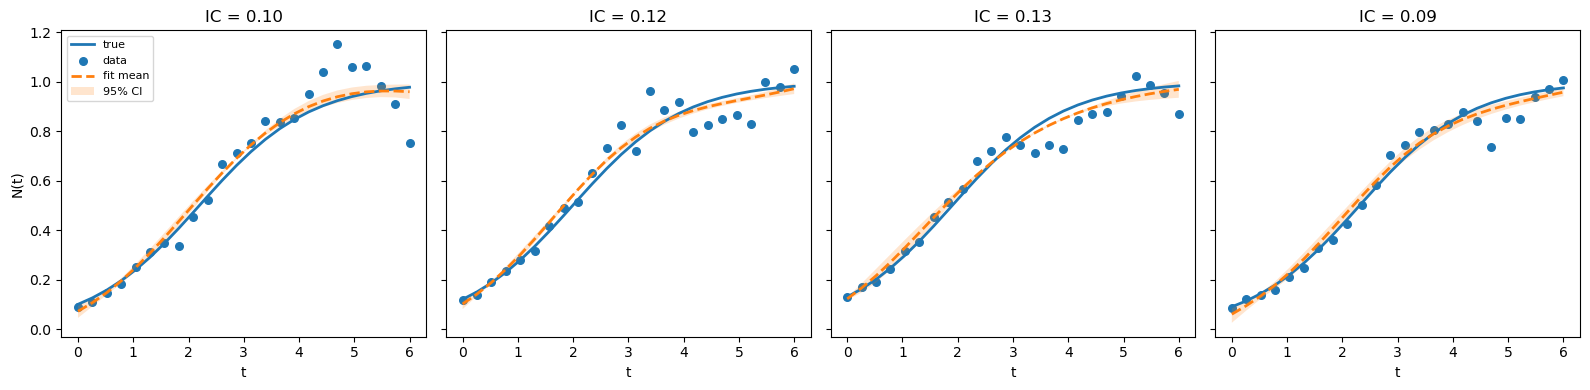

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_72965/1359990907.py:877: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


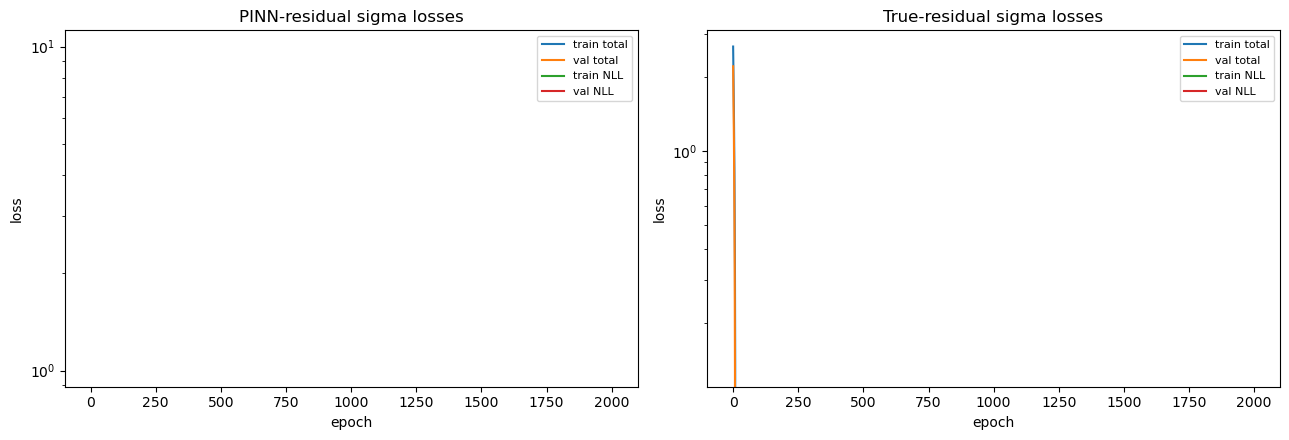


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 4
Synthetic IC values used to generate data: [0.1, 0.12, 0.13, 0.09]
Number of PINN splits: 4
Validation strategy: leave-one-trajectory-out
Validation metric: forward rollout MSE on held-out trajectory
Validation cadence (epochs): 100
Mean best validation loss: 4.878488e-03
Std  best validation loss: 2.401548e-03
Mean best epoch: 1549.00
Std  best epoch: 768.11
IC/N(0) loss weight lambda_ic: 0.000
PINN loss used for model fitting/selection: data + lambda_phys * physics
Separate optimization term: lambda_ic * IC/N(0) loss

Initialization summary by split
-------------------------------
Split 1: heldout_ic=0, dyn_init_seed=10000, sol_init_seeds=[20001, 20002, 20003]
Split 2: heldout_ic=1, dyn_init_seed=10001, sol_init_seeds=[21000, 21002, 21003]
Split 3: heldout_ic=2, dyn_init_seed=10002, sol_init_seeds=[22000, 22001, 22003]
Split 4: heldout_ic=3, dyn_init_seed=10003, sol_init_seeds=[23000, 23001, 23002]

PINN-res

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.10, 0.12, 0.13, 0.09]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# AR(1) heteroscedastic Gaussian NLL
# ============================================================
def ar1_gaussian_nll(resid, sigma, rho, eps=1e-6, reduce="mean"):
    """
    AR(1) heteroscedastic Gaussian negative log-likelihood.

    Model:
        e_0 ~ N(0, sigma_0^2)
        e_k | e_{k-1} ~ N(rho e_{k-1}, (1-rho^2) sigma_k^2)
    """
    resid = resid.reshape(-1)
    sigma = sigma.reshape(-1).clamp_min(eps)

    sigma2 = sigma ** 2
    one_minus_rho2 = max(1.0 - rho ** 2, eps)

    term0 = torch.log(sigma2[0]) + resid[0] ** 2 / sigma2[0]

    innov = resid[1:] - rho * resid[:-1]
    var_innov = one_minus_rho2 * sigma2[1:]
    terms_rest = torch.log(var_innov) + innov ** 2 / var_innov

    terms = torch.cat([term0.view(1), terms_rest], dim=0)

    if reduce == "sum":
        return 0.5 * torch.sum(terms)
    elif reduce == "mean":
        return 0.5 * torch.mean(terms)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def ar1_gaussian_nll_batch(resid_all, sigma_all, rho, eps=1e-6, reduce="mean"):
    """
    resid_all : [B, T, 1] or [B, T]
    sigma_all : [B, T, 1] or [B, T]
    """
    if resid_all.ndim == 2:
        resid_all = resid_all.unsqueeze(-1)
    if sigma_all.ndim == 2:
        sigma_all = sigma_all.unsqueeze(-1)

    B = resid_all.shape[0]
    losses = []
    for b in range(B):
        losses.append(
            ar1_gaussian_nll(
                resid_all[b], sigma_all[b], rho, eps=eps, reduce="mean"
            )
        )
    losses = torch.stack(losses)

    if reduce == "mean":
        return losses.mean()
    elif reduce == "sum":
        return losses.sum()
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law: heteroscedastic + AR(1) correlated in time
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


def sample_ar1_noise_from_sigma(sigma_t, rho):
    """
    Sample heteroscedastic AR(1) noise with marginal std sigma_t.

    e_0 ~ N(0, sigma_0^2)
    e_k = rho e_{k-1} + sqrt(1-rho^2) sigma_k xi_k
    """
    sigma_t = sigma_t.reshape(-1, 1)
    T = sigma_t.shape[0]

    eps = torch.randn_like(sigma_t)
    noise = torch.zeros_like(sigma_t)

    noise[0] = sigma_t[0] * eps[0]
    scale = torch.sqrt(torch.tensor(max(1.0 - rho**2, 1e-8), device=sigma_t.device))

    for k in range(1, T):
        noise[k] = rho * noise[k - 1] + scale * sigma_t[k] * eps[k]

    return noise


y_true_list = []
y_data_list = []
noise_list = []

noise_sig_coeff = 0.1
gamma = 1.0
rho_true = 0.5   # <-- temporal correlation of the synthetic observation noise

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

        sigma_t = noise_sig_coeff * y_true**gamma
        noise_t = sample_ar1_noise_from_sigma(sigma_t, rho=rho_true)
        y_data = y_true + noise_t

        y_true_list.append(y_true)
        y_data_list.append(y_data)
        noise_list.append(noise_t)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, T, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, T, 1]
noise_all  = torch.stack(noise_list,  dim=0)   # [n_ics, T, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = noise_sig_coeff * N_grid**gamma


# ============================================================
# Noise statistics
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    sigma_true_obs_np = (noise_sig_coeff * (y_true_all.squeeze(-1) ** gamma)).cpu().numpy()

    eps = 1e-12
    denom_true = np.maximum(np.abs(y_true_np), eps)
    denom_sym = np.maximum(np.abs(y_true_np) + np.abs(y_data_np), eps)

    pct_error_np = 100.0 * noise_np / denom_true
    abs_pct_error_np = 100.0 * abs_noise_np / denom_true
    smape_np = 100.0 * 2.0 * abs_noise_np / denom_sym

    z_np = noise_np / np.maximum(sigma_true_obs_np, eps)

    print("\nNoise summary: pooled over all ICs and times")
    print("--------------------------------------------")
    print(f"AR(1) rho_true                     : {rho_true: .4f}")
    print(f"Mean signed noise                  : {noise_np.mean(): .6e}")
    print(f"Std of signed noise                : {noise_np.std(ddof=1): .6e}")
    print(f"Mean absolute noise                : {abs_noise_np.mean(): .6e}")
    print(f"Median absolute noise              : {np.median(abs_noise_np): .6e}")
    print(f"RMSE noise                         : {np.sqrt(np.mean(noise_np**2)): .6e}")
    print(f"Max absolute noise                 : {abs_noise_np.max(): .6e}")
    print(f"Mean percentage error (MPE)        : {pct_error_np.mean(): .6f}%")
    print(f"Mean abs percentage error (MAPE)   : {abs_pct_error_np.mean(): .6f}%")
    print(f"Median abs percentage error        : {np.median(abs_pct_error_np): .6f}%")
    print(f"Symmetric MAPE (sMAPE)             : {smape_np.mean(): .6f}%")
    print(f"Mean true sigma(N)                 : {sigma_true_obs_np.mean(): .6e}")
    print(f"Mean |noise| / sigma_true(N)       : {np.mean(abs_noise_np / np.maximum(sigma_true_obs_np, eps)): .6f}")
    print(f"Std of standardized noise z        : {z_np.std(ddof=1): .6f}")
    print(f"Mean of standardized noise z       : {z_np.mean(): .6f}")


# ============================================================
# Optional: pointwise table of true/data/noise/%error
# ============================================================
print("\nObserved-point noise table")
print("--------------------------")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (IC = {N0_list[i]:.2f})")
    print("t        true        data        noise       abs%err     sigma_true    z=noise/sigma")
    for ti, yt, yd, en, ape, sigi, zi in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_np[i],
        y_data_np[i],
        noise_np[i],
        abs_pct_error_np[i],
        sigma_true_obs_np[i],
        z_np[i],
    ):
        print(
            f"{ti:6.3f}   {yt:9.5f}   {yd:9.5f}   {en:9.5f}   "
            f"{ape:9.3f}%   {sigi:11.5e}   {zi:9.4f}"
        )


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def g_zero_nonnegative_penalty(dyn_net):
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


# ============================================================
# Fit sigma using AR(1) likelihood
# ============================================================
def fit_sigma_repeated(
    N_all_seq,              # [B, T, 1]
    resid_all_seq,          # [B, T, 1]
    N_eval_grid,
    N_col_base,
    rho_assumed=0.85,       # <-- assumed temporal correlation in the fit
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=1000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    B = N_all_seq.shape[0]
    use_validation = val_fraction > 0.0 and B > 1

    if use_validation:
        n_val = int(round(val_fraction * B))
        n_val = max(1, min(n_val, B - 1))
    else:
        n_val = 0
    n_train = B - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(B, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all_seq[train_idx]
        r_train = resid_all_seq[train_idx]

        if use_validation:
            N_val = N_all_seq[val_idx]
            r_val = resid_all_seq[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)  # [B, T, 1]
            train_nll = ar1_gaussian_nll_batch(
                r_train, sigma_pred_train, rho=rho_assumed, reduce="mean"
            )
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = ar1_gaussian_nll_batch(
                        r_val, sigma_pred_val, rho=rho_assumed, reduce="mean"
                    )

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e}"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# Example of what to pass into fit_sigma_repeated
# ============================================================
# If residuals are just the observation noise relative to truth:
resid_all_seq = y_data_all - y_true_all    # [B, T, 1]
N_all_seq = y_true_all                     # or your fitted state estimate, shape [B, T, 1]

# Example call:
# sigma_fit_out = fit_sigma_repeated(
#     N_all_seq=N_all_seq,
#     resid_all_seq=resid_all_seq,
#     N_eval_grid=N_grid,
#     N_col_base=N_grid,
#     rho_assumed=0.85,
#     n_repeats=3,
#     val_fraction=0.2,
#     n_epochs=2000,
#     lr=5e-3,
#     hidden_dim=8,
#     lambda_mon=1.0,
#     lambda_reg=1e-5,
#     label="sigma_ar1",
#     print_every=200,
# )


# ============================================================
# Mean percentage error as a function of N
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    noise_np = y_data_np - y_true_np
    abs_noise_np = np.abs(noise_np)

    eps = 1e-12
    abs_pct_error_np = 100.0 * abs_noise_np / np.maximum(np.abs(y_true_np), eps)

    # Flatten all trajectories
    N_flat = y_true_np.reshape(-1)
    pct_flat = abs_pct_error_np.reshape(-1)

    # Bin in N
    n_bins = 20
    bins = np.linspace(N_flat.min(), N_flat.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    mean_pct = np.zeros(n_bins)
    std_pct = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    for i in range(n_bins):
        # include right endpoint in last bin
        if i < n_bins - 1:
            mask = (N_flat >= bins[i]) & (N_flat < bins[i + 1])
        else:
            mask = (N_flat >= bins[i]) & (N_flat <= bins[i + 1])

        if np.sum(mask) > 0:
            mean_pct[i] = pct_flat[mask].mean()
            std_pct[i] = pct_flat[mask].std(ddof=1) if np.sum(mask) > 1 else 0.0
            counts[i] = np.sum(mask)
        else:
            mean_pct[i] = np.nan
            std_pct[i] = np.nan
            counts[i] = 0


# ============================================================
# Plot mean percentage error vs N
# ============================================================
plt.figure(figsize=(6, 4.5))

plt.plot(bin_centers, mean_pct, linewidth=2, label="mean abs % error")

plt.fill_between(
    bin_centers,
    mean_pct - std_pct,
    mean_pct + std_pct,
    alpha=0.25,
    label="±1 std"
)

plt.scatter(N_flat, pct_flat, s=12, alpha=0.15, label="individual points")

plt.xlabel("N")
plt.ylabel("Mean absolute % error")
plt.title("Percentage error vs state N")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Print numeric summary
# ============================================================
print("\nMean percentage error by N bin")
print("--------------------------------")
for c, m, s, n in zip(bin_centers, mean_pct, std_pct, counts):
    if n > 0:
        print(f"N≈{c:.3f} | mean % error = {m:6.3f}% | std = {s:6.3f}% | samples = {int(n)}")



def ar1_gaussian_nll(resid, sigma, rho, eps=1e-6, reduce="mean"):
    """
    resid : [T, 1] or [T]
    sigma : [T, 1] or [T]
    rho   : scalar tensor or float with |rho| < 1
    """
    resid = resid.reshape(-1)
    sigma = sigma.reshape(-1).clamp_min(eps)

    if not torch.is_tensor(rho):
        rho = torch.tensor(rho, dtype=resid.dtype, device=resid.device)

    rho = torch.clamp(rho, -0.999, 0.999)

    sigma2 = sigma ** 2
    one_minus_rho2 = torch.clamp(1.0 - rho ** 2, min=eps)

    term0 = torch.log(sigma2[0]) + resid[0] ** 2 / sigma2[0]

    innov = resid[1:] - rho * resid[:-1]
    var_innov = one_minus_rho2 * sigma2[1:]
    terms_rest = torch.log(var_innov) + innov ** 2 / var_innov

    terms = torch.cat([term0.view(1), terms_rest], dim=0)

    if reduce == "sum":
        return 0.5 * torch.sum(terms)
    elif reduce == "mean":
        return 0.5 * torch.mean(terms)
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def ar1_gaussian_nll_batch(resid_all, sigma_all, rho, eps=1e-6, reduce="mean"):
    """
    resid_all : [B, T, 1] or [B, T]
    sigma_all : [B, T, 1] or [B, T]
    """
    if resid_all.ndim == 2:
        resid_all = resid_all.unsqueeze(-1)
    if sigma_all.ndim == 2:
        sigma_all = sigma_all.unsqueeze(-1)

    losses = []
    for b in range(resid_all.shape[0]):
        losses.append(
            ar1_gaussian_nll(
                resid_all[b], sigma_all[b], rho=rho, eps=eps, reduce="mean"
            )
        )
    losses = torch.stack(losses)

    if reduce == "mean":
        return losses.mean()
    elif reduce == "sum":
        return losses.sum()
    else:
        raise ValueError("reduce must be 'mean' or 'sum'")


def fit_sigma_ar1_repeated(
    N_seq_all,                # [B, T, 1]
    resid_seq_all,            # [B, T, 1]
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma-ar1",
    print_every=500,
):
    B = N_seq_all.shape[0]
    use_validation = val_fraction > 0.0 and B > 1

    if use_validation:
        n_val = int(round(val_fraction * B))
        n_val = max(1, min(n_val, B - 1))
    else:
        n_val = 0
    n_train = B - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    rho_histories = []

    best_val_losses = []
    best_epochs = []
    best_rhos = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(B, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_seq_all[train_idx]
        r_train = resid_seq_all[train_idx]

        if use_validation:
            N_val = N_seq_all[val_idx]
            r_val = resid_seq_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)

        # unconstrained parameter; rho = tanh(rho_raw)
        rho_raw = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=device))

        opt = torch.optim.Adam(
            list(sigma_net.parameters()) + [rho_raw],
            lr=lr,
        )

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None
        best_rho = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            rho = torch.tanh(rho_raw)
            sigma_pred_train = sigma_net(N_train)

            train_nll = ar1_gaussian_nll_batch(
                resid_all=r_train,
                sigma_all=sigma_pred_train,
                rho=rho,
                reduce="mean",
            )
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                rho_eval = torch.tanh(rho_raw)

                if use_validation:
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = ar1_gaussian_nll_batch(
                        resid_all=r_val,
                        sigma_all=sigma_pred_val,
                        rho=rho_eval,
                        reduce="mean",
                    )
                else:
                    val_nll = torch.tensor(np.nan, device=device)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon if use_validation else torch.tensor(np.nan, device=device)

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item() if use_validation else np.nan)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"rho={rho_eval.item(): .4f} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total.item():.6e} | "
                        f"Val NLL: {val_nll.item():.6e} | "
                        f"Val Mon: {val_mon.item():.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"rho={rho_eval.item(): .4f} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e}"
                    )

            criterion = val_total.item() if use_validation else train_total.item()

            if criterion < best_val_loss:
                best_val_loss = criterion
                best_epoch = epoch
                best_rho = torch.tanh(rho_raw).item()
                best_state = {
                    "sigma_net": copy.deepcopy(sigma_net.state_dict()),
                    "rho_raw": rho_raw.detach().clone(),
                }

        sigma_net.load_state_dict(best_state["sigma_net"])
        rho_raw_best = best_state["rho_raw"]
        rho_best = torch.tanh(rho_raw_best).item()
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        rho_histories.append(rho_best)

        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)
        best_rhos.append(rho_best)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | "
            f"Best loss = {best_val_loss:.6e} | "
            f"Best rho = {rho_best:.4f}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "rho_histories": np.array(rho_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_rhos": np.array(best_rhos),
        "best_models": best_models,
    }


import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res

def g_zero_nonnegative_penalty(dyn_net):
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    return torch.sum(torch.relu(-G_zero) ** 2)

@torch.no_grad()
def rollout_with_learned_rhs(dyn_net, y0, t):
    """
    Forward solve dN/dt = dyn_net(N) from initial state y0 over time grid t.
    Returns shape [len(t), 1].
    """
    y_roll = odeint_rk4(lambda tt, yy: dyn_net(yy), y0, t.squeeze()).squeeze(1)
    return y_roll


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit with leave-one-trajectory-out validation
#    - one shared dyn_net
#    - one sol_net per TRAIN trajectory only
#    - one held-out trajectory used only for validation
#    - validation = forward rollout with learned RHS on held-out IC
#    - validation performed every `val_every` epochs
#    - IMPORTANT UPDATE:
#         the N(0) constraint is treated as a separate loss term
#         and is NOT included in the PINN loss used for model selection
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 2000
n_splits = n_ics
print_every = 500
val_every = 100

batch_obs = t_obs.shape[0]
batch_col = 100

lambda_phys = 1.0
lambda_ic = 0.0   # separate IC/N(0) loss weight; not part of PINN loss
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_pinn_total_histories = []
train_data_histories = []
train_phys_histories = []
train_ic_histories = []
train_optim_total_histories = []

val_total_histories = []
val_eval_mask_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    heldout_ic = split
    train_ic_idx = [i for i in range(n_ics) if i != heldout_ic]
    n_train_ics = len(train_ic_idx)

    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"Held-out validation trajectory index: {heldout_ic} | IC = {N0_list[heldout_ic]:.2f}")
    print(f"Training trajectory indices: {train_ic_idx}")
    print(f"{'=' * 90}")

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for local_j, ic_idx in enumerate(train_ic_idx):
        init_seed = sol_init_seed_base + 1000 * split + ic_idx
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_pinn_total_history = []
    train_data_history = []
    train_phys_history = []
    train_ic_history = []
    train_optim_total_history = []

    val_total_history = np.full(n_epochs, np.nan, dtype=np.float64)
    val_eval_mask = np.zeros(n_epochs, dtype=bool)

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_ic_loss = 0.0

        # ----------------------------------------------------
        # Train only on non-held-out trajectories
        # ----------------------------------------------------
        for local_j, ic_idx in enumerate(train_ic_idx):
            sol_net = sol_nets[local_j]

            if batch_obs >= t_obs.shape[0]:
                obs_sel = torch.arange(t_obs.shape[0], device=device)
            else:
                obs_sel = torch.randperm(t_obs.shape[0], device=device)[:batch_obs]

            t_train = t_obs[obs_sel]
            y_train = y_data_all[ic_idx][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)
            phys_loss = phys_loss + g_zero_nonnegative_penalty(dyn_net)

            # ------------------------------------------------
            # Separate initial-condition / N(0) loss
            # ------------------------------------------------
            t0 = torch.zeros((1, 1), dtype=t_obs.dtype, device=device)
            y0_target = y_data_all[ic_idx][0:1]
            N0_pred = sol_net(t0)
            ic_loss = torch.mean((N0_pred - y0_target) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_ic_loss += ic_loss

        total_data_loss /= n_train_ics
        total_phys_loss /= n_train_ics
        total_ic_loss /= n_train_ics

        # PINN loss excludes the N(0) term
        pinn_loss = total_data_loss + lambda_phys * total_phys_loss

        # Optimization loss includes the separate N(0) term if desired
        optim_loss = pinn_loss + lambda_ic * total_ic_loss

        optim_loss.backward()
        optimizer.step()

        train_pinn_total_history.append(pinn_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_ic_history.append(total_ic_loss.item())
        train_optim_total_history.append(optim_loss.item())

        # ----------------------------------------------------
        # Held-out trajectory validation via forward rollout
        # ----------------------------------------------------
        do_validation = (epoch == 0) or ((epoch + 1) % val_every == 0) or (epoch == n_epochs - 1)
        current_val_loss = np.nan

        if do_validation:
            dyn_net.eval()
            for sol_net in sol_nets:
                sol_net.eval()

            with torch.no_grad():
                y0_val = y_data_all[heldout_ic][0:1]
                y_val_target = y_data_all[heldout_ic]
                y_val_roll = rollout_with_learned_rhs(dyn_net, y0_val, t_obs)

                current_val_loss = torch.mean((y_val_roll - y_val_target) ** 2).item()
                val_total_history[epoch] = current_val_loss
                val_eval_mask[epoch] = True

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                best_state = {
                    "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                    "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                    "dyn_init_seed": dyn_init_seed_base + split,
                    "sol_init_seeds": sol_init_seeds_this_split.copy(),
                    "heldout_ic": heldout_ic,
                    "train_ic_idx": train_ic_idx.copy(),
                }

            dyn_net.train()
            for sol_net in sol_nets:
                sol_net.train()

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            val_str = f"{current_val_loss:.6e}" if do_validation else "skipped"
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"PINN Total: {pinn_loss.item():.6e} | "
                f"Optim Total: {optim_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train IC[N(0)]: {total_ic_loss.item():.6e} | "
                f"Heldout Rollout Val: {val_str}"
            )

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Held-out trajectory = {heldout_ic} | "
        f"Best epoch = {best_epoch:5d} | "
        f"Best rollout val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for local_j in range(len(train_ic_idx)):
        sol_nets[local_j].load_state_dict(best_state["sol_nets"][local_j])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for ic_idx in range(n_ics):
            if ic_idx == heldout_ic:
                y0_hold = y_data_all[heldout_ic][0:1]
                traj_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_plot)
                obs_roll = rollout_with_learned_rhs(dyn_net, y0_hold, t_obs)

                trajs_this_split.append(traj_roll.squeeze(1).cpu().numpy())
                obs_fits_this_split.append(obs_roll.squeeze(1).cpu().numpy())
            else:
                local_j = train_ic_idx.index(ic_idx)
                trajs_this_split.append(sol_nets[local_j](t_plot).squeeze(1).cpu().numpy())
                obs_fits_this_split.append(sol_nets[local_j](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_pinn_total_histories.append(train_pinn_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_ic_histories.append(train_ic_history)
    train_optim_total_histories.append(train_optim_total_history)

    val_total_histories.append(val_total_history)
    val_eval_mask_histories.append(val_eval_mask)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_pinn_total_histories = np.array(train_pinn_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_ic_histories = np.array(train_ic_histories)
train_optim_total_histories = np.array(train_optim_total_histories)

val_total_histories = np.array(val_total_histories)
val_eval_mask_histories = np.array(val_eval_mask_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) and rho from pooled multi-IC PINN residual sequences
#    residual = y_data - N_hat
# ============================================================
with torch.no_grad():
    # obs_fit_histories: [n_splits, n_ics, T]
    # Use mean fit across splits for each IC
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    resid_pinn_seq_np = y_data_np - obs_fit_mean_all   # [n_ics, T]
    N_pinn_seq_np = obs_fit_mean_all                   # [n_ics, T]

    # keep only physically meaningful positive states
    N_pinn_seq_np = np.maximum(N_pinn_seq_np, 1e-8)

N_pinn_seq = torch.tensor(N_pinn_seq_np[..., None], dtype=torch.float32, device=device)       # [B,T,1]
resid_pinn_seq = torch.tensor(resid_pinn_seq_np[..., None], dtype=torch.float32, device=device) # [B,T,1]

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_ar1_repeated(
    N_seq_all=N_pinn_seq,
    resid_seq_all=resid_pinn_seq,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma-AR1",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)
rho_pinn_mean = sigma_pinn_results["best_rhos"].mean()


# ============================================================
# 7. Learn sigma_truefit(N) and rho from true residual sequences
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_seq_np = y_true_all.squeeze(-1).cpu().numpy()                  # [n_ics, T]
    resid_true_seq_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy()  # [n_ics, T]

    N_true_seq_np = np.maximum(N_true_seq_np, 1e-8)

N_true_seq = torch.tensor(N_true_seq_np[..., None], dtype=torch.float32, device=device)         # [B,T,1]
resid_true_seq = torch.tensor(resid_true_seq_np[..., None], dtype=torch.float32, device=device)  # [B,T,1]

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_seq.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_ar1_repeated(
    N_seq_all=N_true_seq,
    resid_seq_all=resid_true_seq,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma-AR1",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)
rho_truefit_mean = sigma_truefit_results["best_rhos"].mean()

# ============================================================
# 8. Residual diagnostics across all ICs using mean fit
# ============================================================
with torch.no_grad():
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)   # [n_ics, T]

    residuals_all = y_data_np - obs_fit_mean_all       # [n_ics, T]
    N_fit_all = np.maximum(obs_fit_mean_all, 1e-8)     # [n_ics, T]

    # evaluate learned sigma(N) from PINN residual fit
    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(N_fit_all[..., None], dtype=torch.float32, device=device)
    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()   # [n_ics, T]

    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)   # standardized residuals

    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

    # flattened versions only for plotting
    N_fit_flat = N_fit_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)
    sigma_fit_flat = sigma_fit_all.reshape(-1, 1)
    z_flat = z_all.reshape(-1, 1)

# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"fit mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(train_pinn_total_histories)
train_optim_total_mean, train_optim_total_lo, train_optim_total_hi = mean_and_ci(train_optim_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)

axes[1, 1].plot(epochs_init, train_pinn_total_mean, label="train PINN total")
axes[1, 1].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_optim_total_mean, label="train optimization total")
axes[1, 1].fill_between(epochs_init, train_optim_total_lo, train_optim_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="heldout rollout val")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Separate N(0) loss
# ------------------------------------------------------------
train_ic_mean, train_ic_lo, train_ic_hi = mean_and_ci(train_ic_histories)
axes[1, 2].plot(epochs_init, train_ic_mean, label=r"train IC / $N(0)$ loss")
axes[1, 2].fill_between(epochs_init, train_ic_lo, train_ic_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("IC loss")
axes[1, 2].set_title(r"Separate $N(0)$ constraint loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="fit mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 11b. AR(1) residual diagnostics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(N_fit_flat.squeeze(), np.abs(residuals_flat.squeeze()), s=16, alpha=0.18)
axes[0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    linewidth=2,
    label="learned sigma(N)",
)
axes[0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true sigma(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("|residual|")
axes[0].set_title("Residual magnitude vs state")
axes[0].legend(fontsize=8)

axes[1].scatter(z_prev, z_next, s=18, alpha=0.22)
xmin = min(z_prev.min(), z_next.min())
xmax = max(z_prev.max(), z_next.max())
axes[1].plot([xmin, xmax], [rho_pinn_mean * xmin, rho_pinn_mean * xmax], linewidth=2)
axes[1].set_xlabel(r"$z_{k-1}$")
axes[1].set_ylabel(r"$z_k$")
axes[1].set_title(
    fr"Standardized lag-1 residuals, empirical $\rho \approx {rho_empirical:.3f}$"
)

axes[2].plot(z_prev, label=r"$z_{k-1}$", alpha=0.8)
axes[2].plot(z_next, label=r"$z_k$", alpha=0.8)
axes[2].set_xlabel("flattened lagged sample index")
axes[2].set_ylabel("standardized residual")
axes[2].set_title("Standardized residual sequence pairs")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation strategy: leave-one-trajectory-out")
print(f"Validation metric: forward rollout MSE on held-out trajectory")
print(f"Validation cadence (epochs): {val_every}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"IC/N(0) loss weight lambda_ic: {lambda_ic:.3f}")
print("PINN loss used for model fitting/selection: data + lambda_phys * physics")
print("Separate optimization term: lambda_ic * IC/N(0) loss")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: "
        f"heldout_ic={st['heldout_ic']}, "
        f"dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs fit mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | fit = {mu:8.5f}"
        )

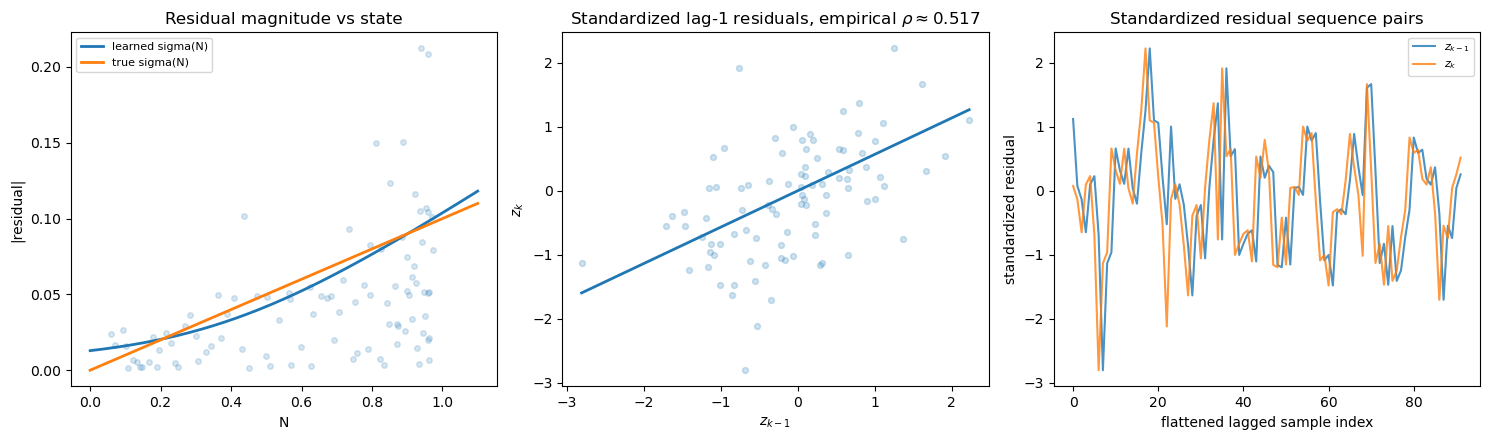

In [ ]:
# ============================================================
# 11b. AR(1) residual diagnostics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(N_fit_flat.squeeze(), np.abs(residuals_flat.squeeze()), s=16, alpha=0.18)
axes[0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    linewidth=2,
    label="learned sigma(N)",
)
axes[0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true sigma(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("|residual|")
axes[0].set_title("Residual magnitude vs state")
axes[0].legend(fontsize=8)

axes[1].scatter(z_prev, z_next, s=18, alpha=0.22)
xmin = min(z_prev.min(), z_next.min())
xmax = max(z_prev.max(), z_next.max())
axes[1].plot([xmin, xmax], [rho_pinn_mean * xmin, rho_pinn_mean * xmax], linewidth=2)
axes[1].set_xlabel(r"$z_{k-1}$")
axes[1].set_ylabel(r"$z_k$")
axes[1].set_title(
    fr"Standardized lag-1 residuals, empirical $\rho \approx {rho_empirical:.3f}$"
)

axes[2].plot(z_prev, label=r"$z_{k-1}$", alpha=0.8)
axes[2].plot(z_next, label=r"$z_k$", alpha=0.8)
axes[2].set_xlabel("flattened lagged sample index")
axes[2].set_ylabel("standardized residual")
axes[2].set_title("Standardized residual sequence pairs")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()